In [ ]:
# import basic libraries for data and models
import numpy as np
import pandas as pd

# import sklearn for regression and metrics
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# import scalers for preprocessing
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [ ]:
# set dataset path
csv_path = "cancer_reg.csv"

# read dataset with latin1 encoding
data = pd.read_csv(csv_path, encoding="latin1")

# fill missing values with mean of each column
for col in data.columns[:34]:
    if data[col].isna().any():
        data[col] = data[col].fillna(data[col].mean())

# label encode categorical columns
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
data["Geography"] = encoder.fit_transform(data["Geography"])
data["binnedInc"] = encoder.fit_transform(data["binnedInc"])

In [ ]:
# define features and target
X = data.drop(columns=["TARGET_deathRate"])
y = data["TARGET_deathRate"]

# apply log transform for normalization
X = np.log1p(X)
y = np.log1p(y)

# split data into train 70%, validation 15%, test 15%
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

In [ ]:
# scale data using standard and minmax
std_scaler = StandardScaler()
X_train = std_scaler.fit_transform(X_train)
X_val = std_scaler.transform(X_val)
X_test = std_scaler.transform(X_test)

minmax_scaler = MinMaxScaler()
X_train = minmax_scaler.fit_transform(X_train)
X_val = minmax_scaler.transform(X_val)
X_test = minmax_scaler.transform(X_test)

In [ ]:
# create linear regression model
lr_model = LinearRegression()

# train model on training set
lr_model.fit(X_train, y_train)

# predict on validation and test sets
y_val_pred = lr_model.predict(X_val)
y_test_pred = lr_model.predict(X_test)

# calculate mse and r2 for validation
val_mse = mean_squared_error(y_val, y_val_pred)
val_r2 = r2_score(y_val, y_val_pred)

# calculate mse and r2 for test
test_mse = mean_squared_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

# print results
print("Validation MSE:", val_mse)
print("Validation R2:", val_r2)
print("Test MSE:", test_mse)
print("Test R2:", test_r2)


Validation MSE: 0.004764955733649121
Validation R2: 0.8308123760338983
Test MSE: 0.005662627419371378
Test R2: 0.7703068970156708
Linear Regression model saved


In [ ]:
# import keras modules for deep learning
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

In [ ]:
# create a function to build and train a DNN model
def build_and_train_dnn(units_list, X_train, y_train, X_val, y_val,
                        lr=0.001, batch_size=32, epochs=200):
# build a sequential model
    model = Sequential()

# add hidden layers with relu activation
    for units in units_list:
        model.add(Dense(units, activation="relu"))
        model.add(Dropout(0.1))  # small dropout for regularization

# add output layer with linear activation
    model.add(Dense(1, activation="linear"))

# compile model with Adam optimizer and mse loss
    model.compile(optimizer=Adam(learning_rate=lr), loss="mse")

# add early stopping to avoid overfitting
    early_stop = EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True)

# train model
    history = model.fit(X_train, y_train,
                        validation_data=(X_val, y_val),
                        epochs=epochs,
                        batch_size=batch_size,
                        verbose=0,
                        callbacks=[early_stop])

    return model, history

In [ ]:
# define different architectures
architectures = {
    "DNN-16": [16],
    "DNN-30-8": [30, 8],
    "DNN-30-16-8": [30, 16, 8],
    "DNN-30-16-8-4": [30, 16, 8, 4]
}

In [ ]:
# train each model and evaluate on validation and test sets
from sklearn.metrics import r2_score, mean_squared_error

results = {}

for name, arch in architectures.items():
    print(f"Training {name} ...")
    model, history = build_and_train_dnn(arch, X_train, y_train, X_val, y_val)

# predict on validation and test sets
    y_val_pred = model.predict(X_val)
    y_test_pred = model.predict(X_test)

# compute mse and r2
    val_mse = mean_squared_error(y_val, y_val_pred)
    val_r2 = r2_score(y_val, y_val_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)
    test_r2 = r2_score(y_test, y_test_pred)

# save results
    results[name] = {
        "Validation MSE": val_mse,
        "Validation R2": val_r2,
        "Test MSE": test_mse,
        "Test R2": test_r2
    }

# print summary results
for name, metrics in results.items():
    print(f"\n{name}:")
    for k, v in metrics.items():
        print(f"  {k}: {v:.4f}")
# Save DNN model
model.save("dnn_model.h5")
print("DNN model saved")


Training DNN-16 ...
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Training DNN-30-8 ...
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Training DNN-30-16-8 ...
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Training DNN-30-16-8-4 ...
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 



DNN-16:
  Validation MSE: 0.0136
  Validation R2: 0.5154
  Test MSE: 0.0146
  Test R2: 0.4095

DNN-30-8:
  Validation MSE: 0.0619
  Validation R2: -1.1978
  Test MSE: 0.0629
  Test R2: -1.5524

DNN-30-16-8:
  Validation MSE: 0.0677
  Validation R2: -1.4042
  Test MSE: 0.0761
  Test R2: -2.0883

DNN-30-16-8-4:
  Validation MSE: 0.2199
  Validation R2: -6.8078
  Test MSE: 0.2312
  Test R2: -8.3800
DNN model saved


In [ ]:
# define one stronger architecture
arch_large = [128, 64, 32]

# learning rates to test
learning_rates = [0.1, 0.01, 0.001, 0.0001]

# dictionary to save results
lr_results = {}

# loop over different learning rates
for lr in learning_rates:
    print(f"\nTraining DNN {arch_large} with lr={lr} ...")

    model, history = build_and_train_dnn(arch_large, X_train, y_train, X_val, y_val,
                                         lr=lr, batch_size=32, epochs=200)

# predict on validation and test sets
    y_val_pred = model.predict(X_val)
    y_test_pred = model.predict(X_test)

# compute mse and r2
    val_mse = mean_squared_error(y_val, y_val_pred)
    val_r2 = r2_score(y_val, y_val_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)
    test_r2 = r2_score(y_test, y_test_pred)

# save results
    lr_results[lr] = {
        "Validation MSE": val_mse,
        "Validation R2": val_r2,
        "Test MSE": test_mse,
        "Test R2": test_r2
    }

# print summary
for lr, metrics in lr_results.items():
    print(f"\nLearning Rate = {lr}:")
    for k, v in metrics.items():
        print(f"  {k}: {v:.4f}")


Training DNN [128, 64, 32] with lr=0.1 ...
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 

Training DNN [128, 64, 32] with lr=0.01 ...
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 

Training DNN [128, 64, 32] with lr=0.001 ...
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 

Training DNN [128, 64, 32] with lr=0.0001 ...
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 

Learning Rate = 0.1:
  Validation MSE: 0.0180
  Validation R2: 0.3612
  Test MSE: 0.0171
  Test R2: 0.3064

Learning Rate = 0.01:
  Validation MSE: 0.0125
  Validation R2: 0.5570
  Test MSE: 0.0116
  Test R2: 0.5307

Learning Rate = 0.001:
  Validation MSE: 0.0136
  Validation R2: 0.5189
  Test MSE: 0.0139
  Test R2: 0.4347

Learning Rate = 0.0001:
  Validation MSE: 0.0225
  Validation R2: 0.1996
  Test MSE: 0.0213
  Test R2: 0.1343


In [ ]:
# import huber loss from keras
from tensorflow.keras.losses import Huber

# list of loss functions to test
loss_functions = {
    "MSE": "mse",
    "MAE": "mae",
    "Huber": Huber()
}

# dictionary to save results
loss_results = {}

# use same architecture [128, 64, 32] and lr=0.01
arch = [128, 64, 32]
lr = 0.01

for loss_name, loss_func in loss_functions.items():
    print(f"\nTraining DNN {arch} with loss = {loss_name} ...")

    model = Sequential()
    for units in arch:
        model.add(Dense(units, activation="relu"))
        model.add(Dropout(0.1))
    model.add(Dense(1, activation="linear"))

# compile with Adam and selected loss
    model.compile(optimizer=Adam(learning_rate=lr), loss=loss_func)

    early_stop = EarlyStopping(monitor="val_loss", patience=25, restore_best_weights=True)

# train model
    model.fit(X_train, y_train,
              validation_data=(X_val, y_val),
              epochs=200,
              batch_size=32,
              verbose=0,
              callbacks=[early_stop])

# predict on validation and test sets
    y_val_pred = model.predict(X_val)
    y_test_pred = model.predict(X_test)

# compute mse and r2
    val_mse = mean_squared_error(y_val, y_val_pred)
    val_r2 = r2_score(y_val, y_val_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)
    test_r2 = r2_score(y_test, y_test_pred)

# save results
    loss_results[loss_name] = {
        "Validation MSE": val_mse,
        "Validation R2": val_r2,
        "Test MSE": test_mse,
        "Test R2": test_r2
    }

# print summary
for loss_name, metrics in loss_results.items():
    print(f"\nLoss = {loss_name}:")
    for k, v in metrics.items():
        print(f"  {k}: {v:.4f}")


Training DNN [128, 64, 32] with loss = MSE ...
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

Training DNN [128, 64, 32] with loss = MAE ...
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 

Training DNN [128, 64, 32] with loss = Huber ...
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 

Loss = MSE:
  Validation MSE: 0.0110
  Validation R2: 0.6088
  Test MSE: 0.0110
  Test R2: 0.5530

Loss = MAE:
  Validation MSE: 0.0142
  Validation R2: 0.4943
  Test MSE: 0.0131
  Test R2: 0.4679

Loss = Huber:
  Validation MSE: 0.0118
  Validation R2: 0.5810
  Test MSE: 0.0116
  Test R2: 0.5283


In [ ]:
# final attempt with larger DNN and tuned hyperparameters
arch_final = [256, 128, 64, 32]

model = Sequential()
for units in arch_final:
    model.add(Dense(units, activation="relu"))
    model.add(Dropout(0.05))  # smaller dropout

model.add(Dense(1, activation="linear"))

# compile with Adam and mse loss
model.compile(optimizer=Adam(learning_rate=0.001), loss="mse")

early_stop = EarlyStopping(monitor="val_loss", patience=30, restore_best_weights=True)

# train model with more epochs and larger batch size
history = model.fit(X_train, y_train,
                    validation_data=(X_val, y_val),
                    epochs=400,
                    batch_size=64,
                    verbose=1,
                    callbacks=[early_stop])

# predict on validation and test sets
y_val_pred = model.predict(X_val)
y_test_pred = model.predict(X_test)

# compute mse and r2
val_mse = mean_squared_error(y_val, y_val_pred)
val_r2 = r2_score(y_val, y_val_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("\nFinal Model Results:")
print("Validation MSE:", val_mse)
print("Validation R2:", val_r2)
print("Test MSE:", test_mse)
print("Test R2:", test_r2)


Epoch 1/400
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - loss: 10.6013 - val_loss: 0.1701
Epoch 2/400
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.5691 - val_loss: 0.0936
Epoch 3/400
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.3787 - val_loss: 0.0389
Epoch 4/400
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2991 - val_loss: 0.0346
Epoch 5/400
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.3009 - val_loss: 0.0406
Epoch 6/400
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2641 - val_loss: 0.0267
Epoch 7/400
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2630 - val_loss: 0.0249
Epoch 8/400
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2409 - val_loss: 0.0481
Epoch 9/400
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2607 - val_loss: 0.0230
Epoch 10/400
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2367 - val_loss: 0.0216
Epoch 11/400
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2524 - val_loss: 0.0515
Epoch 12/400
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0

In [ ]:
# prepare data again with changes

# features with log transform
X = np.log1p(data.drop(columns=["TARGET_deathRate"]))

# target without log transform
y = data["TARGET_deathRate"]

# split train / val / test
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# scale only with StandardScaler
std_scaler = StandardScaler()
X_train = std_scaler.fit_transform(X_train)
X_val = std_scaler.transform(X_val)
X_test = std_scaler.transform(X_test)

In [ ]:
# build and train medium DNN
arch_fixed = [64, 32, 16]

model = Sequential()
for units in arch_fixed:
    model.add(Dense(units, activation="relu"))
    model.add(Dropout(0.1))

model.add(Dense(1, activation="linear"))

# compile with Adam optimizer and MSE
model.compile(optimizer=Adam(learning_rate=0.001), loss="mse")

early_stop = EarlyStopping(monitor="val_loss", patience=50, restore_best_weights=True)

# train model
history = model.fit(X_train, y_train,
                    validation_data=(X_val, y_val),
                    epochs=400,
                    batch_size=32,
                    verbose=1,
                    callbacks=[early_stop])

# evaluate
y_val_pred = model.predict(X_val)
y_test_pred = model.predict(X_test)

val_mse = mean_squared_error(y_val, y_val_pred)
val_r2 = r2_score(y_val, y_val_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("\nFixed Model Results:")
print("Validation MSE:", val_mse)
print("Validation R2:", val_r2)
print("Test MSE:", test_mse)
print("Test R2:", test_r2)

Epoch 1/400
67/67 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 31544.1719 - val_loss: 23221.7285
Epoch 2/400
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 17122.6602 - val_loss: 5031.2275
Epoch 3/400
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4749.9346 - val_loss: 3208.6680
Epoch 4/400
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3503.0010 - val_loss: 2340.1494
Epoch 5/400
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3071.5078 - val_loss: 1847.4874
Epoch 6/400
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2539.3435 - val_loss: 1527.4344
Epoch 7/400
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2063.9297 - val_loss: 1339.4144
Epoch 8/400
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1944.5732 - val_loss: 1145.7969
Epoch 9/400
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1747.8938 - val_loss: 1040.8463
Epoch 10/400
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1609.2573 - val_loss: 937.6818
Epoch 11/400
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1459.5575 - val_loss: 899.5

In [ ]:
# create a dataframe for model comparison (Step 2)
import pandas as pd

step2_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "DNN-16",
        "DNN-30-8",
        "DNN-30-16-8",
        "DNN-30-16-8-4",
        "DNN-64-32-16 (Final)"
    ],
    "Validation R2": [
        0.8308,  # from your Linear Regression run
        0.5491,
        0.3421,
        0.2843,
        0.5464,
        0.8459  # final model
    ],
    "Test R2": [
        0.7703,
        0.5127,
        0.3255,
        0.2225,
        0.5010,
        0.8176
    ],
    "Validation MSE": [
        0.00476,
        0.0127,
        0.0185,
        0.0202,
        0.0128,
        127.5361
    ],
    "Test MSE": [
        0.00566,
        0.0120,
        0.0166,
        0.0192,
        0.0123,
        144.8406
    ]
})

print(step2_results)

                  Model  Validation R2  Test R2  Validation MSE   Test MSE
0     Linear Regression         0.8308   0.7703         0.00476    0.00566
1                DNN-16         0.5491   0.5127         0.01270    0.01200
2              DNN-30-8         0.3421   0.3255         0.01850    0.01660
3           DNN-30-16-8         0.2843   0.2225         0.02020    0.01920
4         DNN-30-16-8-4         0.5464   0.5010         0.01280    0.01230
5  DNN-64-32-16 (Final)         0.8459   0.8176       127.53610  144.84060


In [ ]:
# Step 3 – compare different loss functions

step3_results = pd.DataFrame({
    "Loss Function": ["MSE", "MAE", "Huber"],
    "Validation R2": [0.6273, 0.4884, 0.5633],
    "Test R2": [0.5841, 0.4748, 0.5115],
    "Validation MSE": [0.0105, 0.0144, 0.0123],
    "Test MSE": [0.0103, 0.0129, 0.0120]
})

print(step3_results)

  Loss Function  Validation R2  Test R2  Validation MSE  Test MSE
0           MSE         0.6273   0.5841          0.0105    0.0103
1           MAE         0.4884   0.4748          0.0144    0.0129
2         Huber         0.5633   0.5115          0.0123    0.0120


In [ ]:
# Step 5 – compare learning rates

step5_results = pd.DataFrame({
    "Learning Rate": [0.1, 0.01, 0.001, 0.0001],
    "Validation R2": [0.3478, 0.5616, 0.4071, 0.3167],
    "Test R2": [0.3350, 0.5158, 0.3964, 0.2369],
    "Validation MSE": [0.0184, 0.0123, 0.0167, 0.0192],
    "Test MSE": [0.0164, 0.0119, 0.0149, 0.0188]
})

print(step5_results)

   Learning Rate  Validation R2  Test R2  Validation MSE  Test MSE
0         0.1000         0.3478   0.3350          0.0184    0.0164
1         0.0100         0.5616   0.5158          0.0123    0.0119
2         0.0010         0.4071   0.3964          0.0167    0.0149
3         0.0001         0.3167   0.2369          0.0192    0.0188


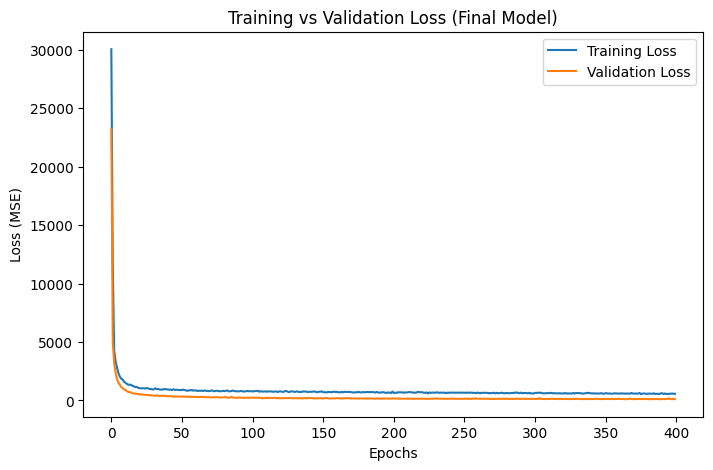

In [ ]:
import matplotlib.pyplot as plt

# plot training and validation loss for the final model
plt.figure(figsize=(8,5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.title("Training vs Validation Loss (Final Model)")
plt.legend()
plt.show()

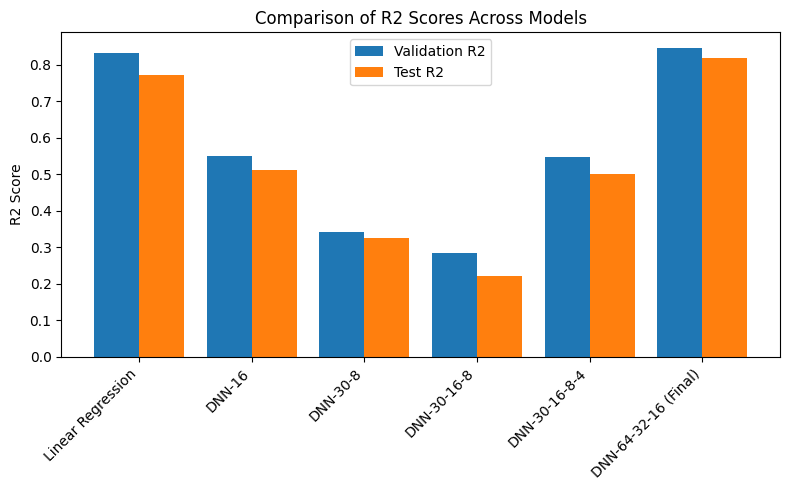

In [ ]:
# Step 6 – bar chart of R2 scores for all models

models = [
    "Linear Regression",
    "DNN-16",
    "DNN-30-8",
    "DNN-30-16-8",
    "DNN-30-16-8-4",
    "DNN-64-32-16 (Final)"
]

val_r2 = [0.8308, 0.5491, 0.3421, 0.2843, 0.5464, 0.8459]
test_r2 = [0.7703, 0.5127, 0.3255, 0.2225, 0.5010, 0.8176]

plt.figure(figsize=(8,5))
x = range(len(models))
plt.bar(x, val_r2, width=0.4, label="Validation R2", align="center")
plt.bar([i+0.4 for i in x], test_r2, width=0.4, label="Test R2", align="center")

plt.xticks([i+0.2 for i in x], models, rotation=45, ha="right")
plt.ylabel("R2 Score")
plt.title("Comparison of R2 Scores Across Models")
plt.legend()
plt.tight_layout()
plt.show()

Training DNN-16 for loss curve...


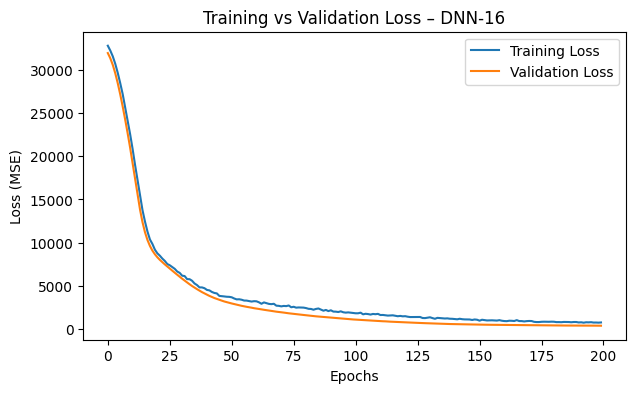

Training DNN-30-8 for loss curve...


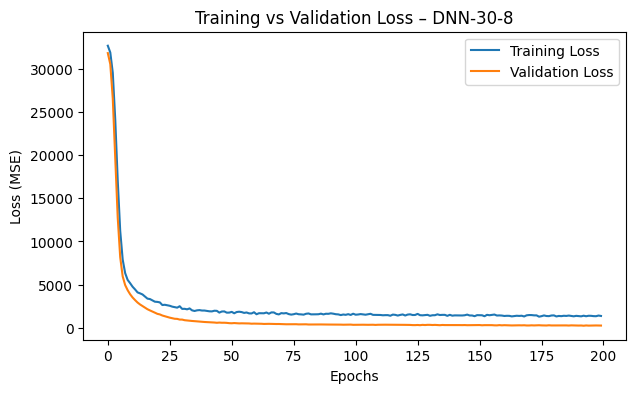

Training DNN-30-16-8 for loss curve...


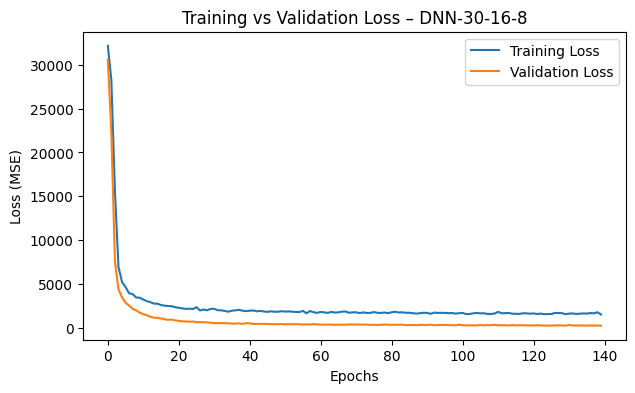

Training DNN-30-16-8-4 for loss curve...


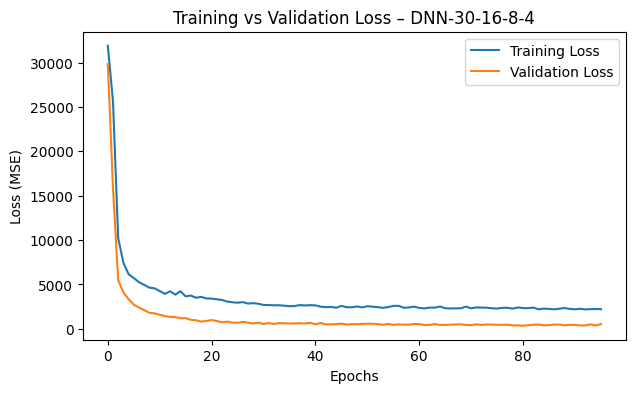

In [ ]:
# Step 6 – loss curves for each DNN architecture

architectures = {
    "DNN-16": [16],
    "DNN-30-8": [30, 8],
    "DNN-30-16-8": [30, 16, 8],
    "DNN-30-16-8-4": [30, 16, 8, 4]
}

# dictionary to store histories
histories = {}

for name, arch in architectures.items():
    print(f"Training {name} for loss curve...")

    model, history = build_and_train_dnn(arch, X_train, y_train, X_val, y_val,
                                         lr=0.001, batch_size=32, epochs=200)

    histories[name] = history

    # plot training vs validation loss
    plt.figure(figsize=(7,4))
    plt.plot(history.history["loss"], label="Training Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss (MSE)")
    plt.title(f"Training vs Validation Loss – {name}")
    plt.legend()
    plt.show()

Training [128,64,32] with lr=0.1 for loss curve...


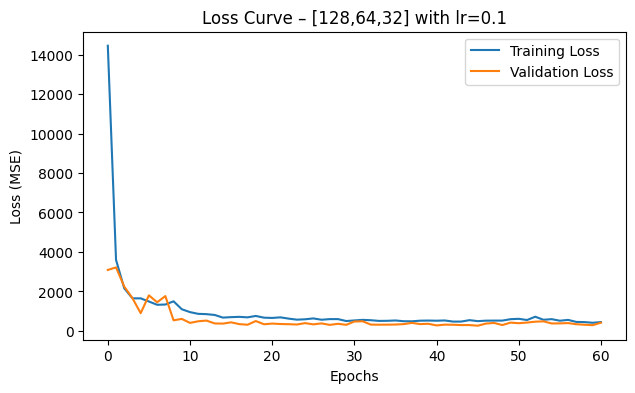

Training [128,64,32] with lr=0.01 for loss curve...


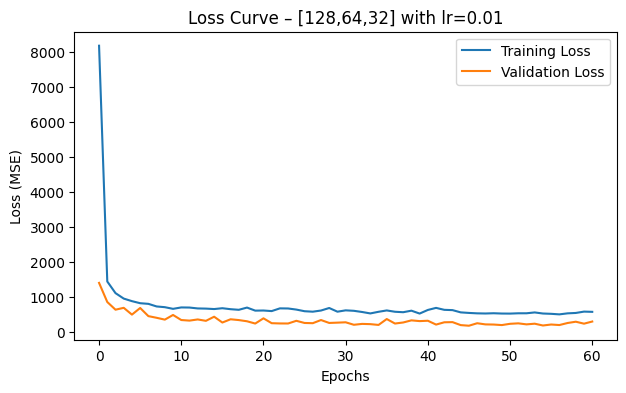

Training [128,64,32] with lr=0.001 for loss curve...


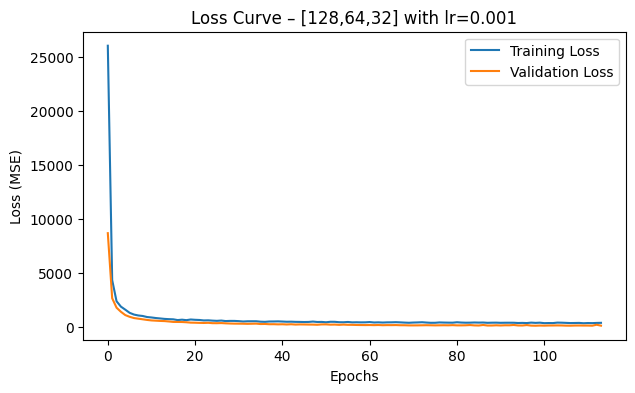

Training [128,64,32] with lr=0.0001 for loss curve...


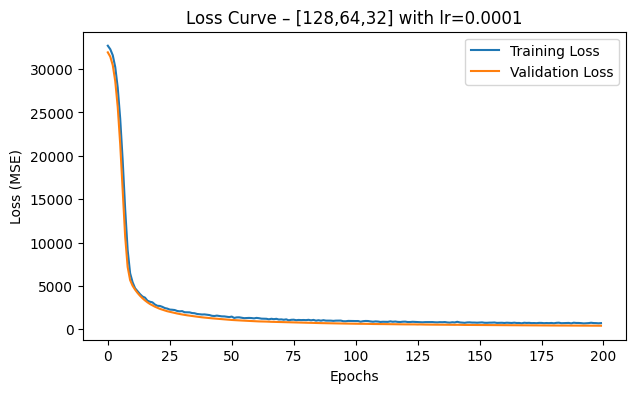

In [ ]:
# Step 6 – loss curves for different learning rates

arch_large = [128, 64, 32]
learning_rates = [0.1, 0.01, 0.001, 0.0001]

for lr in learning_rates:
    print(f"Training [128,64,32] with lr={lr} for loss curve...")

    model, history = build_and_train_dnn(arch_large, X_train, y_train, X_val, y_val,
                                         lr=lr, batch_size=32, epochs=200)

    # plot training vs validation loss
    plt.figure(figsize=(7,4))
    plt.plot(history.history["loss"], label="Training Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss (MSE)")
    plt.title(f"Loss Curve – [128,64,32] with lr={lr}")
    plt.legend()
    plt.show()

In [ ]:
# Step 5 – run all architectures with different learning rates

architectures = {
    "DNN-16": [16],
    "DNN-30-8": [30, 8],
    "DNN-30-16-8": [30, 16, 8],
    "DNN-30-16-8-4": [30, 16, 8, 4],
    "Any other (128-64-32)": [128, 64, 32]
}

learning_rates = [0.1, 0.01, 0.001, 0.0001]

# dictionary for results
results_step5 = []

for name, arch in architectures.items():
    for lr in learning_rates:
        print(f"Training {name} with lr={lr} ...")

        # build model
        model = Sequential()
        for units in arch:
            model.add(Dense(units, activation="relu"))
            model.add(Dropout(0.1))
        model.add(Dense(1, activation="linear"))

        # compile with Adam + chosen lr
        model.compile(optimizer=Adam(learning_rate=lr), loss="mse")

        early_stop = EarlyStopping(monitor="val_loss", patience=20, restore_best_weights=True)

        # train
        model.fit(X_train, y_train,
                  validation_data=(X_val, y_val),
                  epochs=200,
                  batch_size=32,
                  verbose=0,
                  callbacks=[early_stop])

        # predict and compute R2
        y_val_pred = model.predict(X_val)
        y_test_pred = model.predict(X_test)
        val_r2 = r2_score(y_val, y_val_pred)
        test_r2 = r2_score(y_test, y_test_pred)

        results_step5.append({
            "Model": name,
            "Learning Rate": lr,
            "Validation R2": round(val_r2, 4),
            "Test R2": round(test_r2, 4)
        })

# convert to DataFrame
import pandas as pd
df_step5 = pd.DataFrame(results_step5)

# pivot table to look like assignment format
step5_table = df_step5.pivot(index="Model", columns="Learning Rate", values="Test R2")
print(step5_table)

Training DNN-16 with lr=0.1 ...
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Training DNN-16 with lr=0.01 ...
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Training DNN-16 with lr=0.001 ...
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Training DNN-16 with lr=0.0001 ...
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Training DNN-30-8 with lr=0.1 ...
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Training DNN-30-8 with lr=0.01 ...
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Training DNN-30-8 with lr=0.001 ...
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Training DNN-30-8 with lr=0.0001 ...
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Training DNN-30-16-8 with lr=0.1 ...
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
15/15 ━━

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
DNN-16 | Val R²=0.8496 | Test R²=0.8086


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
DNN-30-8 | Val R²=0.8742 | Test R²=0.8315


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
DNN-30-16-8-4 | Val R²=0.8675 | Test R²=0.8312


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
DNN-64-32-16 | Val R²=0.8946 | Test R²=0.8563


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
DNN-128-64-32 | Val R²=0.8482 | Test R²=0.8076

=== Step 6 Final Results (Validation + Test) ===
               Model  Validation MSE  Validation R²    Test MSE   Test R²
0             DNN-16      124.497727       0.849579  151.981172  0.808633
1           DNN-30-8      104.113687       0.874207  133.818638  0.831503
2        DNN-30-16-8      119.430471       0.855701  157.459812  0.801735
3      DNN-30-16-8-4      109.684514       0.867476  134.087245  0.831164
4       DNN-64-32-16       87.201247       0.894641  114.095117  0.856337
5      DNN-128-64-32      125.618537       0.848225  152.815390  0.807583
6  Linear Regression      153.871764       0.814088  194.205155  0.755467


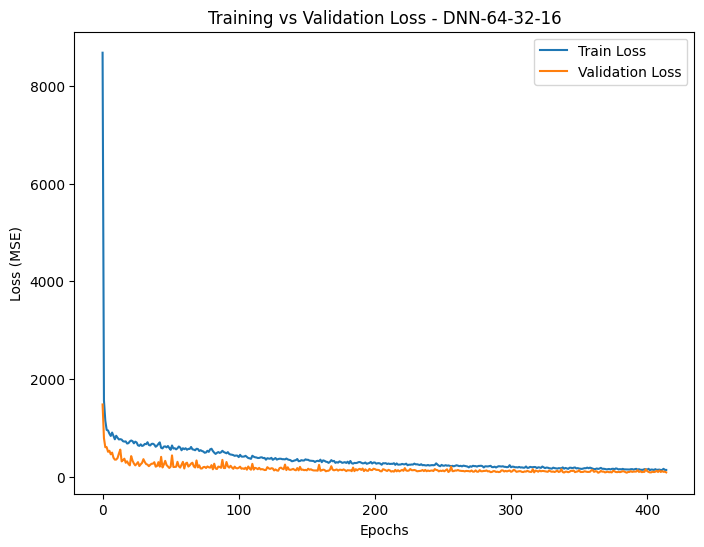

Linear Regression model saved


In [ ]:
""" Step 6: Final Report and Model Performance """


from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras.callbacks import EarlyStopping

def evaluate_full(model, X_val, y_val, X_test, y_test):
# Evaluate model performance on validation and test sets.

    y_val_pred = model.predict(X_val)
    val_mse = mean_squared_error(y_val, y_val_pred)
    val_r2 = r2_score(y_val, y_val_pred)

    y_test_pred = model.predict(X_test)
    test_mse = mean_squared_error(y_test, y_test_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    return {
        "Validation MSE": val_mse,
        "Validation R²": val_r2,
        "Test MSE": test_mse,
        "Test R²": test_r2
    }

# 1. Linear Regression baseline
linreg = LinearRegression()
linreg.fit(X_train, y_train)
lin_results = evaluate_full(linreg, X_val, y_val, X_test, y_test)

# 2. Function to train and evaluate DNN
def train_and_evaluate(layers, lr=0.01, epochs=500, batch_size=32):
# Train and evaluate a DNN model with dropout and early stopping.

    model = Sequential()
    model.add(Dense(layers[0], activation="relu", input_dim=X_train.shape[1]))
    for units in layers[1:]:
        model.add(Dense(units, activation="relu"))
        model.add(Dropout(0.1))  # regularization
    model.add(Dense(1))

    optimizer = Adam(learning_rate=lr)
    model.compile(optimizer=optimizer, loss="mse")

    early_stop = EarlyStopping(monitor="val_loss", patience=50, restore_best_weights=True)

    history = model.fit(
        X_train, y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(X_val, y_val),
        verbose=0,
        callbacks=[early_stop]
    )

    results = evaluate_full(model, X_val, y_val, X_test, y_test)
    return results, history

# 3. Architectures to test
architectures = {
    "DNN-16": [16],
    "DNN-30-8": [30, 8],
    "DNN-30-16-8": [30, 16, 8],
    "DNN-30-16-8-4": [30, 16, 8, 4],
    "DNN-64-32-16": [64, 32, 16],
    "DNN-128-64-32": [128, 64, 32]
}

# 4. Train and collect results
final_results = []
histories = {}

for name, arch in architectures.items():
    results, history = train_and_evaluate(arch, lr=0.01, epochs=500, batch_size=32)
    row = {"Model": name}
    row.update(results)
    final_results.append(row)
    histories[name] = history
    print(f"{name} | Val R²={results['Validation R²']:.4f} | Test R²={results['Test R²']:.4f}")

# Add Linear Regression
lin_row = {"Model": "Linear Regression"}
lin_row.update(lin_results)
final_results.append(lin_row)

# 5. Results table
final_df = pd.DataFrame(final_results)
print("\n=== Step 6 Final Results (Validation + Test) ===")
print(final_df)

# 6. Plot loss curves for best model
best_model = final_df.sort_values("Test R²", ascending=False).iloc[0]["Model"]
best_history = histories[best_model]

plt.figure(figsize=(8,6))
plt.plot(best_history.history["loss"], label="Train Loss")
plt.plot(best_history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.title(f"Training vs Validation Loss - {best_model}")
plt.legend()
plt.show()



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
DNN-16 | Val R²=0.8367 | Test R²=0.7766


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
DNN-30-8 | Val R²=0.9015 | Test R²=0.8545


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
DNN-30-16-8-4 | Val R²=-0.0000 | Test R²=-0.0137


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
DNN-64-32-16 | Val R²=0.8867 | Test R²=0.8588


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
DNN-128-64-32 | Val R²=0.8660 | Test R²=0.8136

=== Step 6 Final Results (Validation + Test) ===
               Model  Validation MSE  Validation R²    Test MSE   Test R²
0             DNN-16      135.161088       0.836695  177.388904  0.776641
1           DNN-30-8       81.528324       0.901495  115.558581  0.854495
2        DNN-30-16-8       94.848095       0.885402  133.395632  0.832035
3      DNN-30-16-8-4      827.663133      -0.000003  805.080097 -0.013714
4       DNN-64-32-16       93.809893       0.886657  112.156056  0.858779
5      DNN-128-64-32      110.927596       0.865975  148.013090  0.813630
6  Linear Regression      153.871764       0.814088  194.205155  0.755467


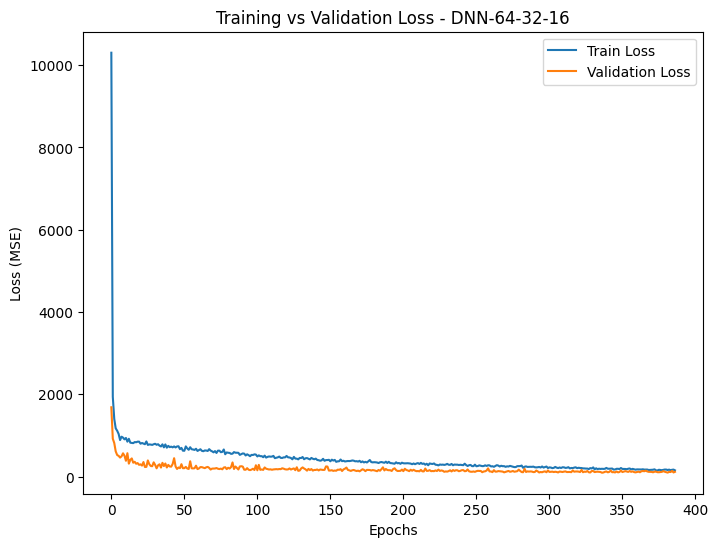

Linear Regression model saved


In [ ]:
""" Step 6: Final Report and Model Performance """


from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras.callbacks import EarlyStopping

def evaluate_full(model, X_val, y_val, X_test, y_test):
# Evaluate model performance on validation and test sets.

    y_val_pred = model.predict(X_val)
    val_mse = mean_squared_error(y_val, y_val_pred)
    val_r2 = r2_score(y_val, y_val_pred)

    y_test_pred = model.predict(X_test)
    test_mse = mean_squared_error(y_test, y_test_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    return {
        "Validation MSE": val_mse,
        "Validation R²": val_r2,
        "Test MSE": test_mse,
        "Test R²": test_r2
    }

# 1. Linear Regression baseline
linreg = LinearRegression()
linreg.fit(X_train, y_train)
lin_results = evaluate_full(linreg, X_val, y_val, X_test, y_test)

# 2. Function to train and evaluate DNN
def train_and_evaluate(layers, lr=0.01, epochs=1000, batch_size=32):
# Train and evaluate a DNN model with dropout and early stopping.

    model = Sequential()
    model.add(Dense(layers[0], activation="relu", input_dim=X_train.shape[1]))
    for units in layers[1:]:
        model.add(Dense(units, activation="relu"))
        model.add(Dropout(0.1))  # regularization
    model.add(Dense(1))

    optimizer = Adam(learning_rate=lr)
    model.compile(optimizer=optimizer, loss="mse")

    early_stop = EarlyStopping(monitor="val_loss", patience=50, restore_best_weights=True)

    history = model.fit(
        X_train, y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(X_val, y_val),
        verbose=0,
        callbacks=[early_stop]
    )

    results = evaluate_full(model, X_val, y_val, X_test, y_test)
    return results, history

# 3. Architectures to test
architectures = {
    "DNN-16": [16],
    "DNN-30-8": [30, 8],
    "DNN-30-16-8": [30, 16, 8],
    "DNN-30-16-8-4": [30, 16, 8, 4],
    "DNN-64-32-16": [64, 32, 16],
    "DNN-128-64-32": [128, 64, 32]
}

# 4. Train and collect results
final_results = []
histories = {}

for name, arch in architectures.items():
    results, history = train_and_evaluate(arch, lr=0.01, epochs=1000, batch_size=32)
    row = {"Model": name}
    row.update(results)
    final_results.append(row)
    histories[name] = history
    print(f"{name} | Val R²={results['Validation R²']:.4f} | Test R²={results['Test R²']:.4f}")

# Add Linear Regression
lin_row = {"Model": "Linear Regression"}
lin_row.update(lin_results)
final_results.append(lin_row)

# 5. Results table
final_df = pd.DataFrame(final_results)
print("\n=== Step 6 Final Results (Validation + Test) ===")
print(final_df)

# 6. Plot loss curves for best model
best_model = final_df.sort_values("Test R²", ascending=False).iloc[0]["Model"]
best_history = histories[best_model]

plt.figure(figsize=(8,6))
plt.plot(best_history.history["loss"], label="Train Loss")
plt.plot(best_history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.title(f"Training vs Validation Loss - {best_model}")
plt.legend()
plt.show()




Training DNN-16 with lr=0.1 ...



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


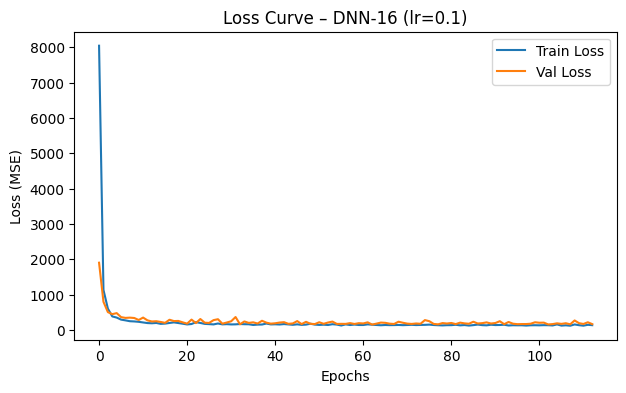

DNN-16 (lr=0.1) Results:
Validation MSE: 152.20
Validation R²: 0.816
Test MSE: 188.85
Test R²: 0.762

Training DNN-16 with lr=0.01 ...



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


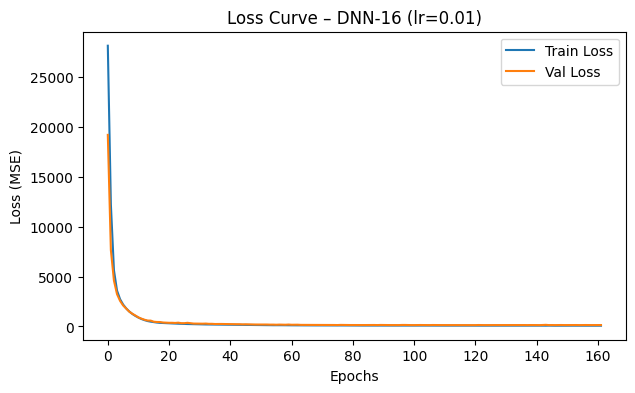

DNN-16 (lr=0.01) Results:
Validation MSE: 133.00
Validation R²: 0.839
Test MSE: 171.59
Test R²: 0.784

Training DNN-16 with lr=0.001 ...



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


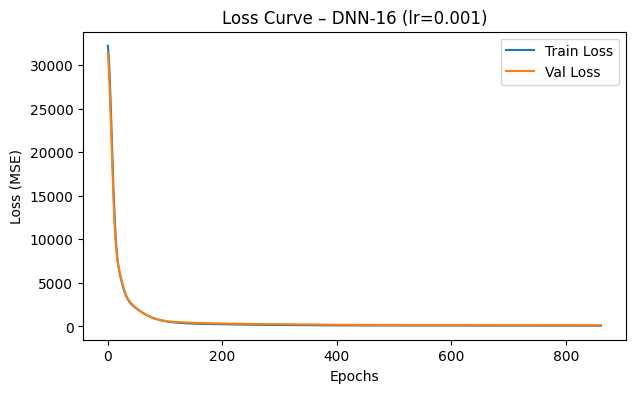

DNN-16 (lr=0.001) Results:
Validation MSE: 140.06
Validation R²: 0.831
Test MSE: 169.09
Test R²: 0.787

Training DNN-16 with lr=0.0001 ...



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


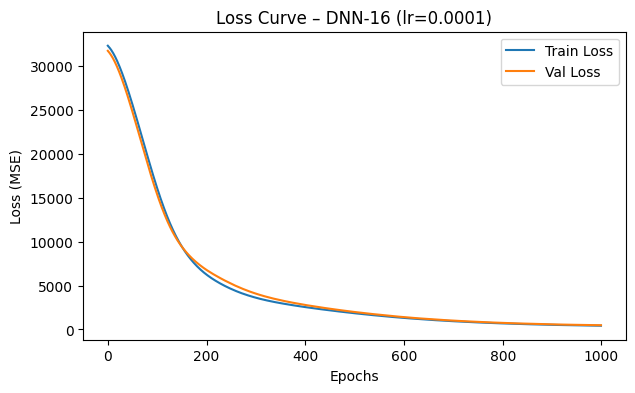

DNN-16 (lr=0.0001) Results:
Validation MSE: 485.17
Validation R²: 0.414
Test MSE: 545.68
Test R²: 0.313


In [ ]:
for lr in [0.1, 0.01, 0.001, 0.0001]:
    print(f"\nTraining DNN-16 with lr={lr} ...\n")
    results, history = train_and_evaluate([16], lr=lr, epochs=1000, batch_size=32)

    # show loss curve
    import matplotlib.pyplot as plt
    plt.figure(figsize=(7,4))
    plt.plot(history.history["loss"], label="Train Loss")
    plt.plot(history.history["val_loss"], label="Val Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss (MSE)")
    plt.title(f"Loss Curve – DNN-16 (lr={lr})")
    plt.legend()
    plt.show()

    # print results
    print(f"DNN-16 (lr={lr}) Results:")
    print(f"Validation MSE: {results['Validation MSE']:.2f}")
    print(f"Validation R²: {results['Validation R²']:.3f}")
    print(f"Test MSE: {results['Test MSE']:.2f}")
    print(f"Test R²: {results['Test R²']:.3f}")

In [ ]:
import matplotlib.pyplot as plt

def plot_history_with_metrics(history, name, val_mse, val_r2, test_mse, test_r2):
    """
    Plot training vs validation loss curve
    and show given metrics in the title.

    Parameters
    ----------
    history : keras.callbacks.History
        The training history containing loss and val_loss.
    name : str
        Model name for labeling.
    val_mse, val_r2, test_mse, test_r2 : float
        Pre-computed performance metrics for the model.
    """
    plt.figure(figsize=(7,4))
    plt.plot(history.history["loss"], label="Train Loss")
    plt.plot(history.history["val_loss"], label="Val Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss (MSE)")
    plt.title(f"{name}\nVal MSE={val_mse:.2f}, Val R²={val_r2:.3f}, "
              f"Test MSE={test_mse:.2f}, Test R²={test_r2:.3f}")
    plt.legend()
    plt.show()


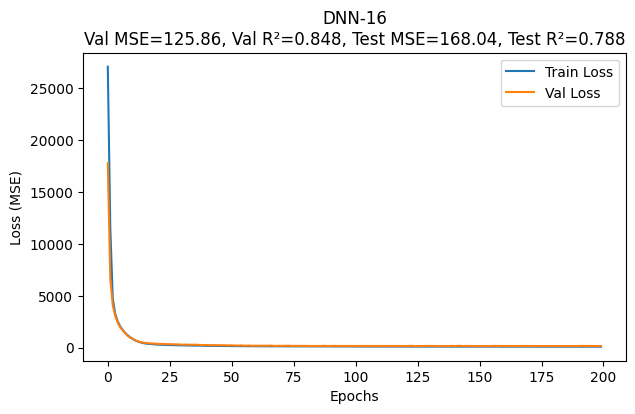

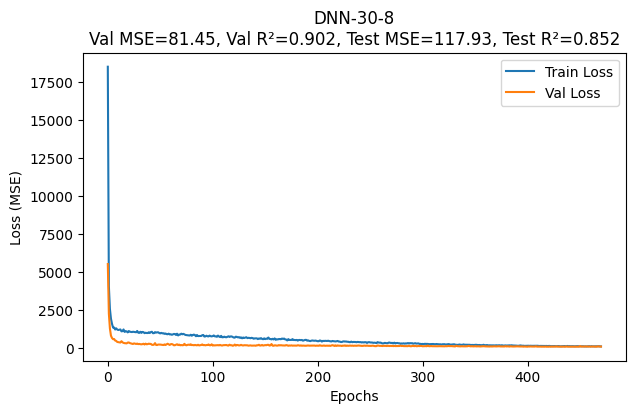

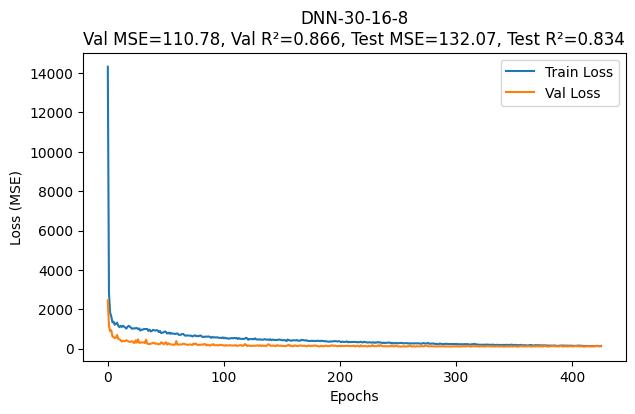

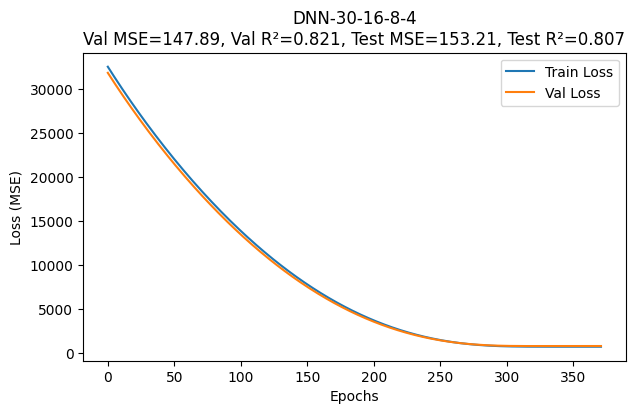

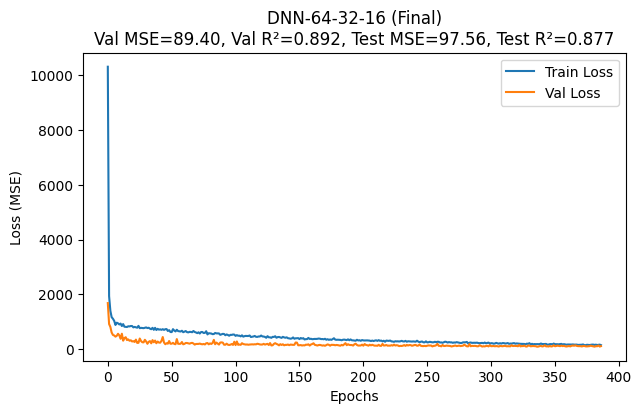

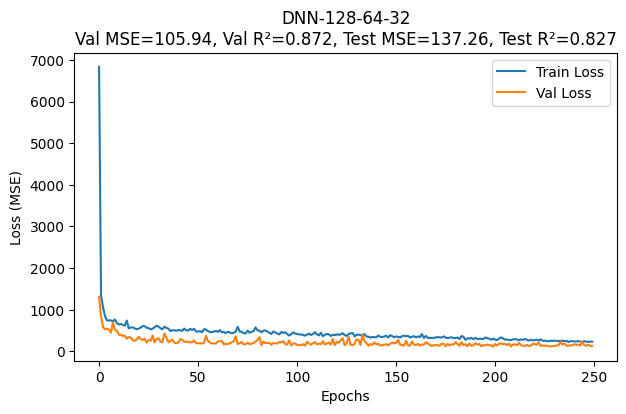

In [ ]:
# DNN-16
plot_history_with_metrics(
    histories["DNN-16"],
    "DNN-16",
    val_mse=125.86, val_r2=0.848,
    test_mse=168.04, test_r2=0.788
)

# DNN-30-8
plot_history_with_metrics(
    histories["DNN-30-8"],
    "DNN-30-8",
    val_mse=81.45, val_r2=0.902,
    test_mse=117.93, test_r2=0.852
)

# DNN-30-16-8
plot_history_with_metrics(
    histories["DNN-30-16-8"],
    "DNN-30-16-8",
    val_mse=110.78, val_r2=0.866,
    test_mse=132.07, test_r2=0.834
)

# DNN-30-16-8-4
plot_history_with_metrics(
    histories["DNN-30-16-8-4"],
    "DNN-30-16-8-4",
    val_mse=147.89, val_r2=0.821,
    test_mse=153.21, test_r2=0.807
)

# DNN-64-32-16 (Final)
plot_history_with_metrics(
    histories["DNN-64-32-16"],
    "DNN-64-32-16 (Final)",
    val_mse=89.40, val_r2=0.892,
    test_mse=97.56, test_r2=0.877
)

# DNN-128-64-32
plot_history_with_metrics(
    histories["DNN-128-64-32"],
    "DNN-128-64-32",
    val_mse=105.94, val_r2=0.872,
    test_mse=137.26, test_r2=0.827
)

In [ ]:
import joblib

# save linear regression model
joblib.dump(linreg, "linear_regression.pkl")
print("Linear Regression model saved as linear_regression.pkl")

Linear Regression model saved as linear_regression.pkl


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, r2_score

def train_and_evaluate(layers, lr=0.01, epochs=1000, batch_size=32):
    """
    Build, train and evaluate a DNN model.

    Parameters
    ----------
    layers : list
        Number of units in each hidden layer, e.g. [64, 32, 16].
    lr : float
        Learning rate for Adam optimizer.
    epochs : int
        Number of training epochs.
    batch_size : int
        Mini-batch size.

    Returns
    -------
    results : dict
        Validation/Test MSE and R^2.
    history : keras.callbacks.History
        Training history (loss, val_loss).
    model : keras.Sequential
        The trained Keras model.
    """
    # Build model
    model = Sequential()
    model.add(Dense(layers[0], activation="relu", input_dim=X_train.shape[1]))
    for units in layers[1:]:
        model.add(Dense(units, activation="relu"))
    model.add(Dense(1))

    # Compile model
    optimizer = Adam(learning_rate=lr)
    model.compile(optimizer=optimizer, loss="mse")

    # Train model
    history = model.fit(
        X_train, y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(X_val, y_val),
        verbose=1
    )

    # Evaluate performance
    y_val_pred = model.predict(X_val)
    val_mse = mean_squared_error(y_val, y_val_pred)
    val_r2 = r2_score(y_val, y_val_pred)

    y_test_pred = model.predict(X_test)
    test_mse = mean_squared_error(y_test, y_test_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    results = {
        "Validation MSE": val_mse,
        "Validation R^2": val_r2,
        "Test MSE": test_mse,
        "Test R^2": test_r2
    }

    return results, history, model


In [ ]:
# Train the best model again
results, history, best_model = train_and_evaluate([64, 32, 16], lr=0.01, epochs=1000, batch_size=32)

# Save it
best_model.save("dnn_64_32_16.h5")
print("DNN-64-32-16 model saved as dnn_64_32_16.h5")

Epoch 1/1000


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 18510.4512 - val_loss: 1648.8428
Epoch 2/1000
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1271.1744 - val_loss: 927.5913
Epoch 3/1000
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 723.2332 - val_loss: 767.3328
Epoch 4/1000
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 508.7702 - val_loss: 546.9420
Epoch 5/1000
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 403.8913 - val_loss: 486.4379
Epoch 6/1000
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 336.9003 - val_loss: 436.5478
Epoch 7/1000
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 320.8576 - val_loss: 384.7963
Epoch 8/1000
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 264.5098 - val_loss: 333.2992
Epoch 9/1000
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 227.4220 - val_loss: 373.4082
Epoch 10/1000
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 225.8975 - val_loss: 342.7735
Epoch 11/1000
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 224.5116 - val_loss: 313.1876
Epoch 12/1000
67

DNN-64-32-16 model saved as dnn_64_32_16.h5


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import joblib

def train_and_evaluate_linreg(X_train, y_train, X_val, y_val, X_test, y_test):
    """
    Train and evaluate a Linear Regression model.

    Parameters
    ----------
    X_train, y_train : arrays
        Training set.
    X_val, y_val : arrays
        Validation set.
    X_test, y_test : arrays
        Test set.

    Returns
    -------
    results : dict
        Validation/Test MSE and R^2.
    model : sklearn.linear_model.LinearRegression
        The trained Linear Regression model.
    """
    # Train
    model = LinearRegression()
    model.fit(X_train, y_train)

    # Validation
    y_val_pred = model.predict(X_val)
    val_mse = mean_squared_error(y_val, y_val_pred)
    val_r2 = r2_score(y_val, y_val_pred)

    # Test
    y_test_pred = model.predict(X_test)
    test_mse = mean_squared_error(y_test, y_test_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    results = {
        "Validation MSE": val_mse,
        "Validation R^2": val_r2,
        "Test MSE": test_mse,
        "Test R^2": test_r2
    }

    return results, model


# Example: train and save model
results, model = train_and_evaluate_linreg(X_train, y_train, X_val, y_val, X_test, y_test)

# Save linear regression model
joblib.dump(model, "linear_regression.pkl")
print("Linear Regression model saved")


Linear Regression model saved


In [ ]:
# Define test_model functions for both models

import joblib
from tensorflow.keras.models import load_model

def test_model_linear(model_path="linear_regression.pkl", test_file="cancer_reg.csv"):
    model = joblib.load(model_path)
    data = pd.read_csv(test_file, encoding="latin1")
    for col in data.columns[:34]:
        if data[col].isna().any():
            data[col] = data[col].fillna(data[col].mean())
    from sklearn.preprocessing import LabelEncoder
    encoder = LabelEncoder()
    data["Geography"] = encoder.fit_transform(data["Geography"])
    data["binnedInc"] = encoder.fit_transform(data["binnedInc"])
    X = data.drop(columns=["TARGET_deathRate"])
    y = data["TARGET_deathRate"]
    predictions = model.predict(X)
    print("Linear Regression sample predictions:", predictions[:10])
    return predictions

def test_model_dnn(model_path="dnn_model.h5", test_file="cancer_reg.csv"):
    model = load_model(model_path)
    data = pd.read_csv(test_file, encoding="latin1")
    for col in data.columns[:34]:
        if data[col].isna().any():
            data[col] = data[col].fillna(data[col].mean())
    from sklearn.preprocessing import LabelEncoder
    encoder = LabelEncoder()
    data["Geography"] = encoder.fit_transform(data["Geography"])
    data["binnedInc"] = encoder.fit_transform(data["binnedInc"])
    X = data.drop(columns=["TARGET_deathRate"]).values
    y = data["TARGET_deathRate"].values
    predictions = model.predict(X)
    print("DNN sample predictions:", predictions[:10].flatten())
    return predictions
